In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
project_path = "/content/drive/MyDrive/Group 7 Capstone Project"
images_path = f"{project_path}/DC_images"
csv_path = f"{project_path}/scenicness_dataset.csv"

In [4]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# Load embeddings
embeddings_path = f"{project_path}/embeddings/clip_embeddings.npy"
embeddings = np.load(embeddings_path)

embeddings.shape

(997, 512)

In [5]:
pca = PCA(n_components=50)
pcs = pca.fit_transform(embeddings)

pcs.shape

(997, 50)

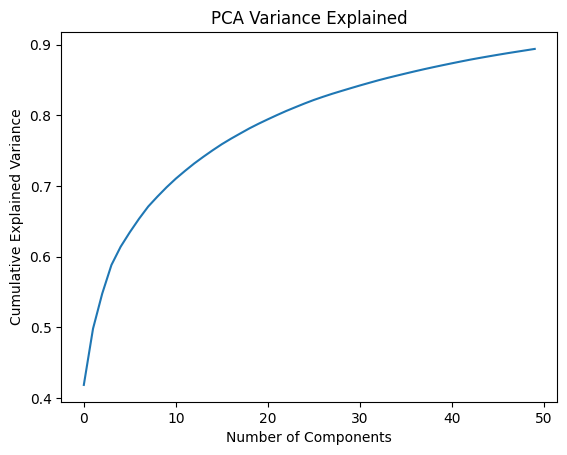

In [6]:
import matplotlib.pyplot as plt

# Plot explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.show()

In [7]:
pca.explained_variance_ratio_

array([0.41847077, 0.07964177, 0.04963523, 0.04046985, 0.02582747,
       0.02060726, 0.01900202, 0.01737219, 0.01405084, 0.01326292,
       0.01213775, 0.01098927, 0.01047554, 0.00954746, 0.0091046 ,
       0.00863523, 0.0078133 , 0.00735221, 0.00725425, 0.00659174,
       0.00621748, 0.00600633, 0.0058017 , 0.00536046, 0.00526992,
       0.00495549, 0.00448703, 0.00426288, 0.00397073, 0.00390764,
       0.00383963, 0.00368541, 0.00363565, 0.00337833, 0.00319578,
       0.00314453, 0.00309083, 0.00298394, 0.00284232, 0.00275905,
       0.00268675, 0.00263478, 0.00254734, 0.00237849, 0.00227573,
       0.00221846, 0.00216299, 0.00206208, 0.0020342 , 0.00203072],
      dtype=float32)

In [ ]:
np.save(f"{project_path}/embeddings/clip_pca_50.npy", pcs)

In [ ]:
import pandas as pd

df = pd.read_csv(csv_path)
df.head()

,scenicness,connectivity,objects,description,id,latitude,longitude,image_path,greenery_pct,building_pct,sky_pct,road_pct,water_pct
0,0,0,"['text (Sorry, we have no imagery here)']",A blank image with a central message stating t...,5513,38.865521,-77.009026,DC_images/dc_5513.jpg,0.000977,0.00000,99.999023,0.00000,0.0
1,0,0,"[""text: 'Sorry, we have no imagery here.'""]","A blank, featureless screen with a message sta...",3274,38.939376,-77.055174,DC_images/dc_3274.jpg,0.000977,0.00000,99.999023,0.00000,0.0
2,6,2,"['trees', 'fallen branches', 'leaf litter', 'f...","A forest scene with dense trees, leaf-covered ...",8371,38.879924,-76.951403,DC_images/dc_8371.jpg,40.528320,0.00000,3.852295,0.00000,0.0
3,0,0,"[""text: 'Sorry, we have no imagery here.'""]",This image displays a blank background with a ...,3500,38.935775,-77.050558,DC_images/dc_3500.jpg,0.000977,0.00000,99.999023,0.00000,0.0
4,3,6,"['houses', 'cars', 'trash bins', 'power lines'...",A residential street lined with brick row hous...,1912,38.950170,-77.082869,DC_images/dc_1912.jpg,6.958984,17.61084,30.894531,2.39624,0.0


In [ ]:
df_pca = pd.DataFrame(pcs, columns=[f"pc_{i+1}" for i in range(50)])
df_merged = pd.concat([df.reset_index(drop=True), df_pca], axis=1)

df_merged.to_csv(f"{project_path}/scenicness_dataset_with_pca.csv", index=False)
df_merged.head()

,scenicness,connectivity,objects,description,id,latitude,longitude,image_path,greenery_pct,building_pct,...,pc_41,pc_42,pc_43,pc_44,pc_45,pc_46,pc_47,pc_48,pc_49,pc_50
0,0,0,"['text (Sorry, we have no imagery here)']",A blank image with a central message stating t...,5513,38.865521,-77.009026,DC_images/dc_5513.jpg,0.000977,0.00000,...,-0.000886,0.003947,-0.005451,0.000870,-0.004981,0.003068,0.000109,0.001984,-0.001231,0.000246
1,0,0,"[""text: 'Sorry, we have no imagery here.'""]","A blank, featureless screen with a message sta...",3274,38.939376,-77.055174,DC_images/dc_3274.jpg,0.000977,0.00000,...,-0.000939,0.003918,-0.005455,0.000891,-0.005006,0.003083,0.000083,0.001964,-0.001252,0.000175
2,6,2,"['trees', 'fallen branches', 'leaf litter', 'f...","A forest scene with dense trees, leaf-covered ...",8371,38.879924,-76.951403,DC_images/dc_8371.jpg,40.528320,0.00000,...,0.177784,-0.367039,0.196975,0.567869,0.054331,-0.253802,-0.036296,0.066133,-0.107136,0.084274
3,0,0,"[""text: 'Sorry, we have no imagery here.'""]",This image displays a blank background with a ...,3500,38.935775,-77.050558,DC_images/dc_3500.jpg,0.000977,0.00000,...,-0.000953,0.003925,-0.005454,0.000895,-0.004999,0.003078,0.000081,0.001963,-0.001251,0.000160
4,3,6,"['houses', 'cars', 'trash bins', 'power lines'...",A residential street lined with brick row hous...,1912,38.950170,-77.082869,DC_images/dc_1912.jpg,6.958984,17.61084,...,-0.412387,0.091788,-0.088130,-0.202182,0.182022,-0.014951,-0.214586,-0.184804,0.271504,0.122767
